In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading the file into google colab environment

df = pd.read_csv("/content/Telco churn clean.csv")

In [ ]:
#Checking columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'expected_total', 'charge_difference', 'percentage_difference',
       'average_historical_monthly_charge', 'monthly_charge_change'],
      dtype='object')

Overall churn distribution

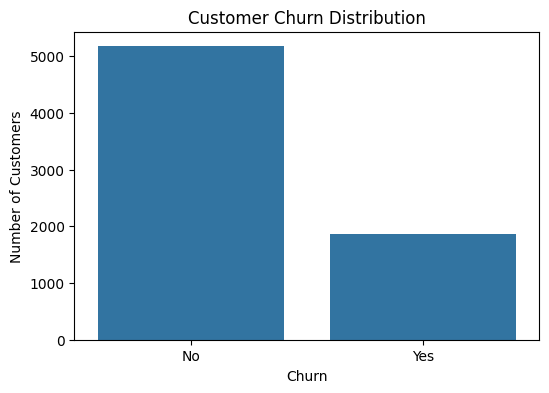

In [ ]:
#Count number of churned and non-churned customers

churn_counts = df['Churn'].value_counts()
#plot churn distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x= 'Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
#calculate % of churned and non-churned customers

churn_percentage = df['Churn'].value_counts(normalize=True)*100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Customer demographic analysis

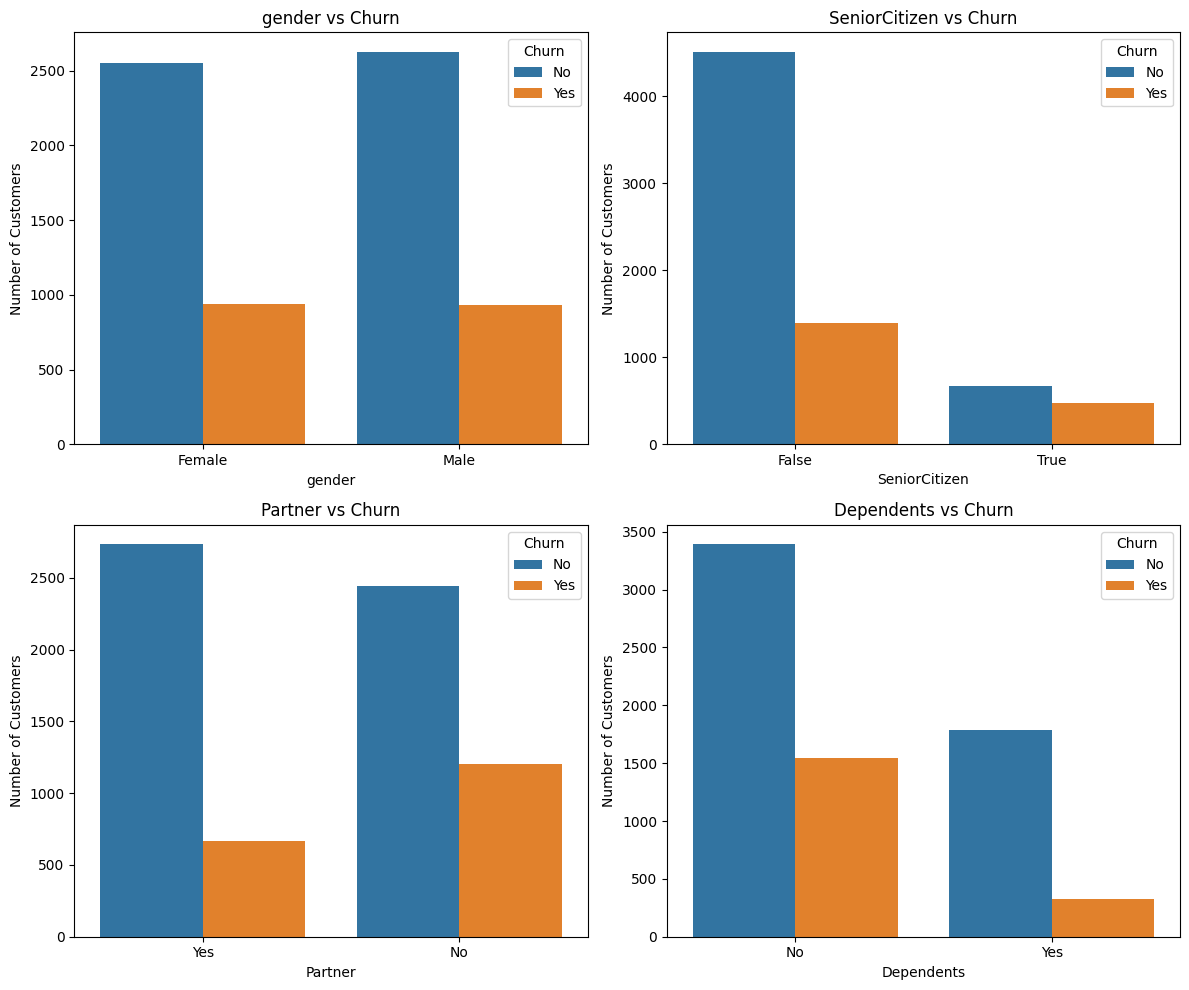

In [ ]:
# Columns to analyze against Churn
columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

# Create count plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, column in zip(axes.flat, columns):
    sns.countplot(data=df, x=column, hue='Churn', ax=ax)

    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Number of Customers')

    # Add legend
    ax.legend(title='Churn')

plt.tight_layout()
plt.show()

In [ ]:
#Columns to be analyzed

columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
#calculate  % of churn for these columns
for column in columns:
    churn_rate = (
        df.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(2)
    )

    print(f"\n{column}")
    print(churn_rate)


gender
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
False    23.61
True     41.68
Name: Churn, dtype: float64

Partner
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


Customer Tenure Analysis

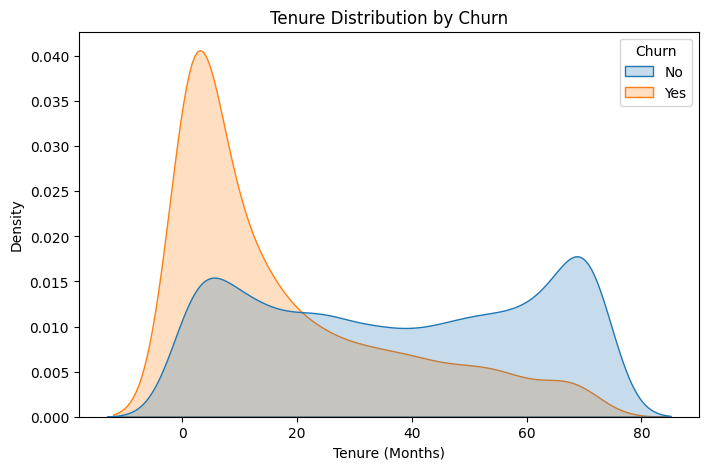

In [ ]:

#plot tenure vs churn
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x='tenure',
    hue='Churn',
    fill=True,
    common_norm=False
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')

plt.show()

In [ ]:
#Create tenure groups

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6', '7-12', '13-24', '25-48', '49-72']
)
#calculate churn rate for each tenure group
churn_rate_tenure = (
    df.groupby('tenure_group', observed=False)['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(churn_rate_tenure)

tenure_group
0-6      53.33
7-12     35.89
13-24    28.71
25-48    20.39
49-72     9.51
Name: Churn, dtype: float64


Monthly Charge Analysis

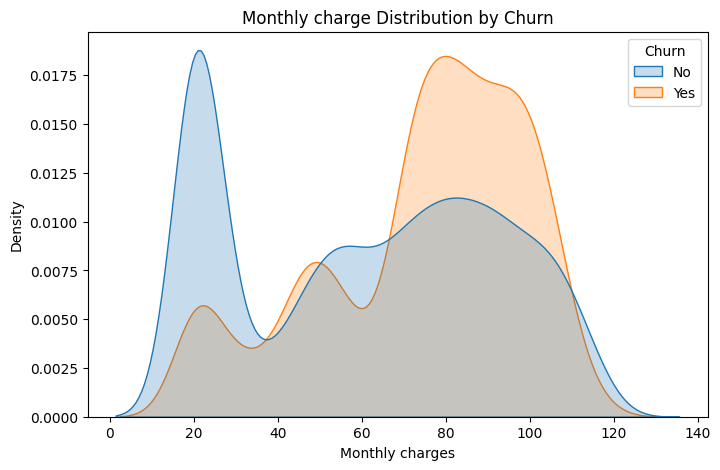

In [ ]:
#plot monthly charge by churn

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    fill=True,
    common_norm=False
)

plt.title('Monthly charge Distribution by Churn')
plt.xlabel('Monthly charges')
plt.ylabel('Density')

plt.show()

In [ ]:
# Create monthly charge groups
df['monthly_charge_group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120, 150],
    labels=['0-30', '31-60', '61-90', '91-120', '121-150']
)

# Calculate churn rate for each group
churn_rate = (
    df.groupby('monthly_charge_group', observed=False)['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(churn_rate)

monthly_charge_group
0-30        9.80
31-60      25.93
61-90      33.91
91-120     32.78
121-150      NaN
Name: Churn, dtype: float64


Total Charge Analysis

In [ ]:
# Create total charge groups
df['total_charge_group'] = pd.cut(
    df['TotalCharges'],
    bins=[0, 1737, 3474, 5211, 6948, 8685],
    labels=['0-1737', '1738-3474', '3475-5211', '5212-6948','6949-8685']
)

# Calculate churn rate for each group
churn_rate = (
    df.groupby('total_charge_group', observed=False)['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(churn_rate)

total_charge_group
0-1737       32.93
1738-3474    24.58
3475-5211    16.70
5212-6948    14.71
6949-8685    10.69
Name: Churn, dtype: float64


Contract type analysis

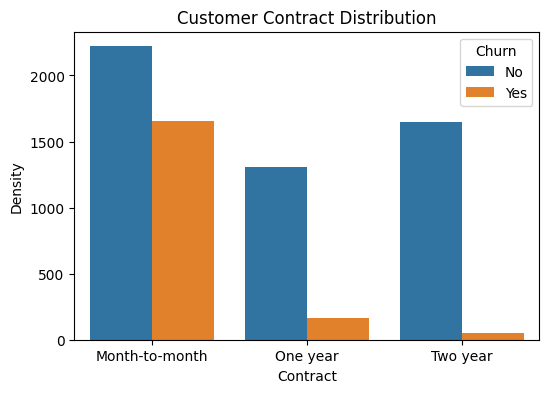

In [ ]:
#calcute values in each contract categories
contract_counts = df['Contract'].value_counts()

#plot contract categories aganist churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x= 'Contract',hue = 'Churn')
plt.title('Customer Contract Distribution')
plt.xlabel('Contract')
plt.ylabel('Density')
plt.show()

In [ ]:
# Calculate churn rate for each contract type
churn_rate = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
      .reset_index(name='Churn_Rate')
)

# Display the result
print(churn_rate)


         Contract  Churn_Rate
0  Month-to-month       42.71
1        One year       11.27
2        Two year        2.83


Internet service analysis

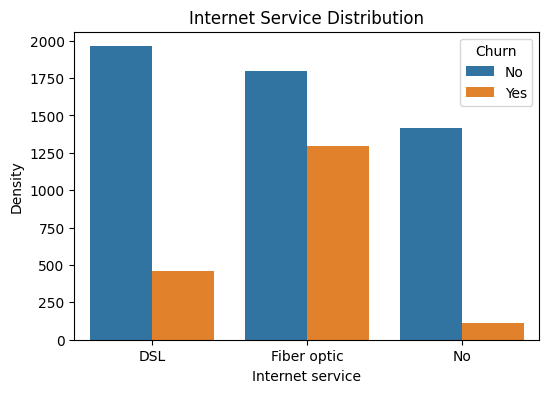

In [ ]:
#calculate values in internetservice categories

internet_counts = df['InternetService'].value_counts()

#plot internet services aganist churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x= 'InternetService',hue = 'Churn')
plt.title('Internet Service Distribution')
plt.xlabel('Internet service')
plt.ylabel('Density')
plt.show()

In [ ]:
# Calculate churn rate for each service type
churn_rate = (
    df.groupby('InternetService')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
      .reset_index(name='Churn_Rate')
)

# Display the result
print(churn_rate)

  InternetService  Churn_Rate
0             DSL       18.96
1     Fiber optic       41.89
2              No        7.40


Additional service analysis

In [ ]:
columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV','StreamingMovies']
for column in columns:
    churn_rate = (
        df.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(2)
    )

    print(f"\n{column}")
    print(churn_rate)


OnlineSecurity
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Churn, dtype: float64

TechSupport
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

StreamingTV
StreamingTV
No                     33.52
No internet service     7.40
Yes                    30.07
Name: Churn, dtype: float64

StreamingMovies
StreamingMovies
No                     33.68
No internet service     7.40
Yes                    29.94
Name: Churn, dtype: float64


Phone service analysis

In [ ]:
# Calculate churn rate for PhoneService
phone_churn_rate = (
    df.groupby('PhoneService')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(phone_churn_rate)


PhoneService
No     24.93
Yes    26.71
Name: Churn, dtype: float64


In [ ]:
# Calculate churn rate for MultipleLines
multiple_lines_churn_rate = (
    df.groupby('MultipleLines')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(multiple_lines_churn_rate)

MultipleLines
No                  25.04
No phone service    24.93
Yes                 28.61
Name: Churn, dtype: float64


Payment method analysis

In [ ]:
# Calculate churn rate for PaymentMethod
payment_method_churn_rate = (
    df.groupby('PaymentMethod')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(payment_method_churn_rate)

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


Paperless billing analysis

In [ ]:
# Calculate churn rate for Paperless billing
paperless_billing_churn_rate = (
    df.groupby('PaperlessBilling')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

print(paperless_billing_churn_rate)

PaperlessBilling
No     16.33
Yes    33.57
Name: Churn, dtype: float64


**Multivariant** **Analysis**

Combined billing behavior analysis

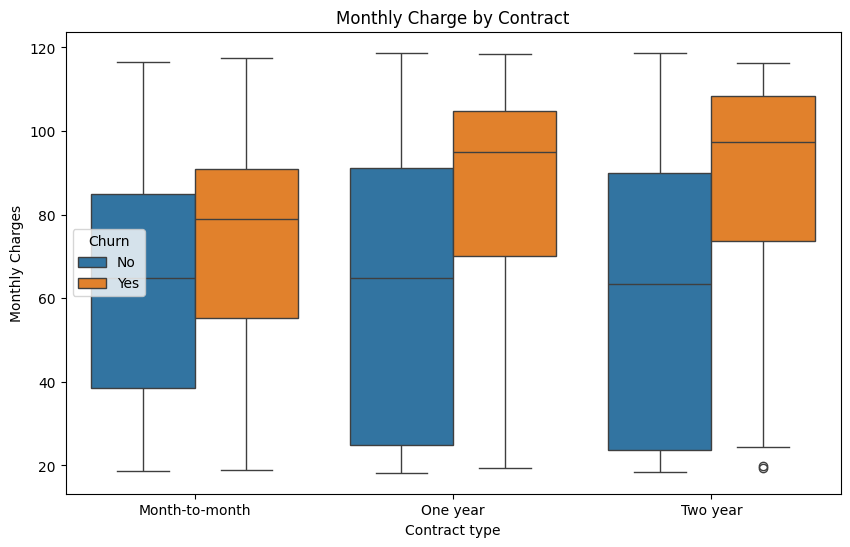

In [ ]:
#set the figure size for better readibility
plt.figure(figsize=(10,6))
 #Create box plot
sns.boxplot(data= df, x='Contract', y = 'MonthlyCharges', hue='Churn')

#add title and labels
plt.title("Monthly Charge by Contract")
plt.xlabel('Contract type')
plt.ylabel('Monthly Charges')

#Display the plot
plt.show()

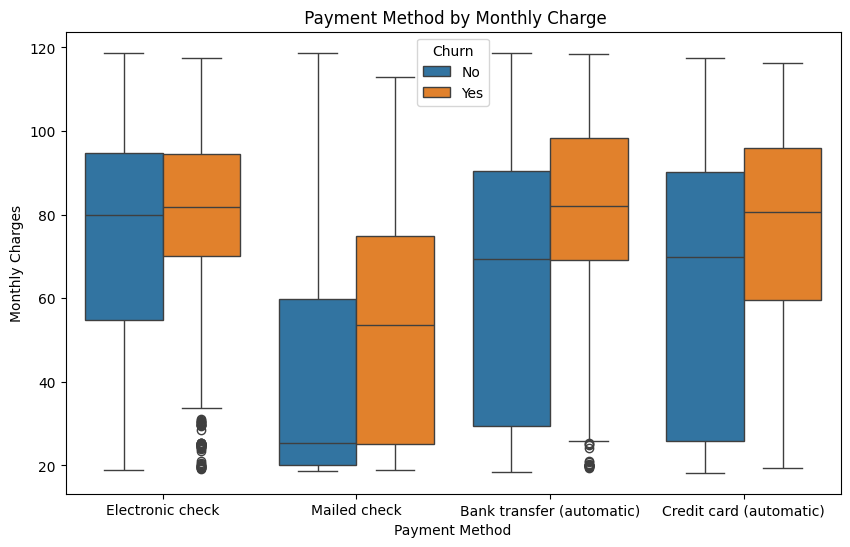

In [ ]:
#set the figure size for better readibility
plt.figure(figsize=(10,6))
 #Create box plot
sns.boxplot(data= df, x='PaymentMethod', y = 'MonthlyCharges', hue='Churn')

#add title and labels
plt.title(" Payment Method by Monthly Charge")
plt.xlabel('Payment Method')
plt.ylabel('Monthly Charges')

#Display the plot
plt.show()

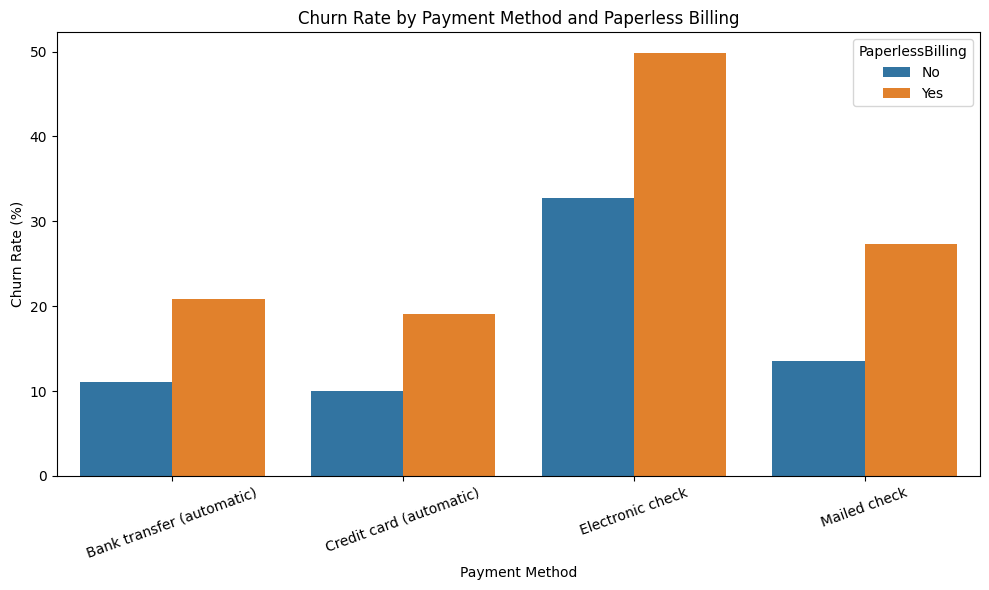

In [ ]:
# Calculate churn rate for each Payment Method + Paperless Billing combination
churn_rate = (
    df.groupby(['PaymentMethod', 'PaperlessBilling'])['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

# Create grouped bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=churn_rate,
    x='PaymentMethod',
    y='ChurnRate',
    hue='PaperlessBilling'
)

# Add labels and title
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method and Paperless Billing')

# Rotate x-axis labels for readability
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

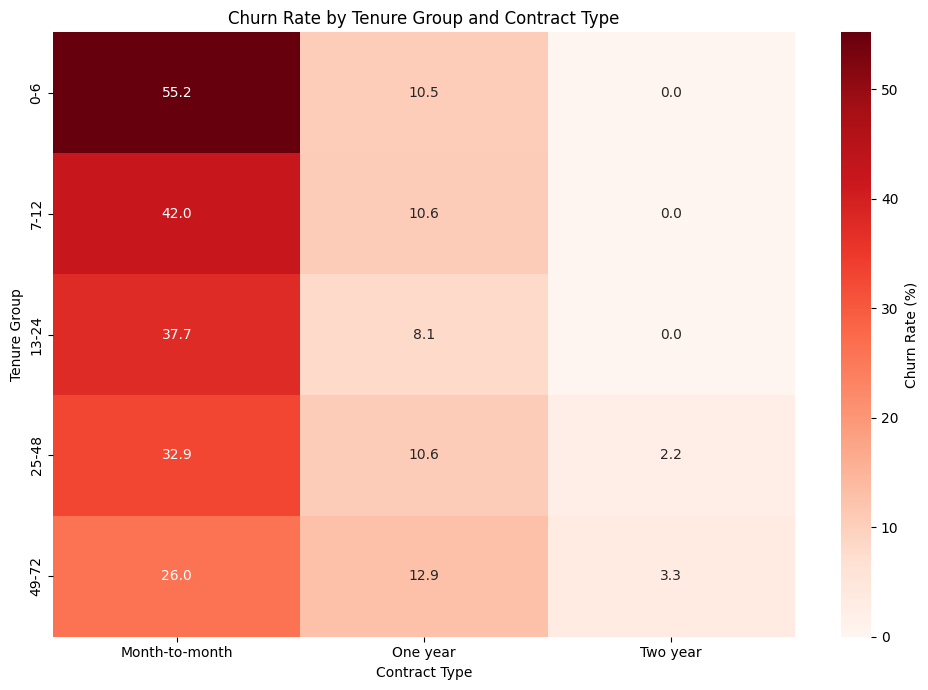

In [ ]:

# -------------------------------------------------------
# 2. Calculate churn rate for each combination
#    of tenure group and contract type
# -------------------------------------------------------
churn_rate = (
    df
    .groupby(['tenure_group', 'Contract'], observed=False)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

# -------------------------------------------------------
# 3. Convert the data into a format suitable for heatmap
# -------------------------------------------------------
heatmap_data = churn_rate.pivot(
    index='tenure_group',
    columns='Contract',
    values='ChurnRate'
)

# -------------------------------------------------------
# 4. Create the heatmap
# -------------------------------------------------------
plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    annot=True,          # Display churn rate inside cells
    fmt='.1f',           # Show one decimal place
    cmap='Reds',
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title('Churn Rate by Tenure Group and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Tenure Group')

plt.tight_layout()
plt.show()

Service combination analysis

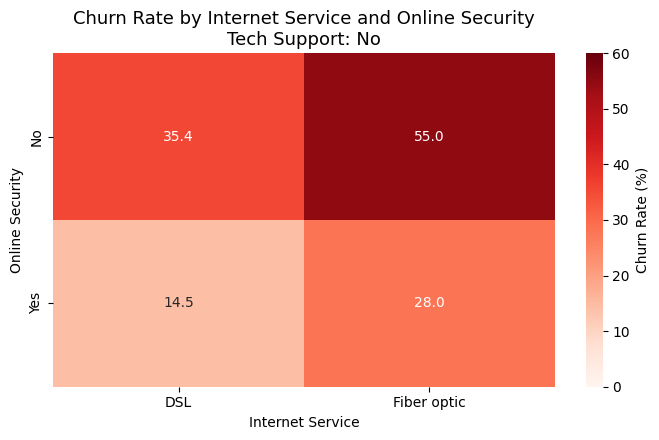

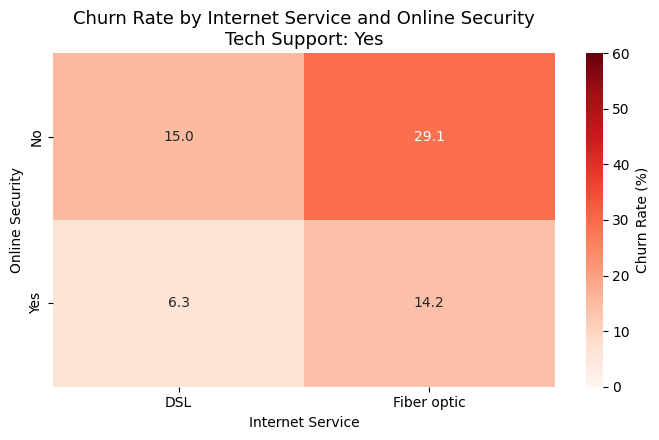

In [ ]:
# ---------------------------------------------------------
# 1. Calculate churn rate for each combination
# ---------------------------------------------------------

# Group customers by:
# - Internet Service
# - Online Security
# - Tech Support
#
# Then calculate the mean of Churn.
# Assuming Churn is already encoded as 0 = No and 1 = Yes.
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No':0})
churn_analysis = (
    df.groupby(
        ['InternetService', 'OnlineSecurity', 'TechSupport']
    )['Churn']
    .mean()
    .reset_index()
)

# Convert churn rate from proportion to percentage
churn_analysis['Churn'] = churn_analysis['Churn'] * 100


# ---------------------------------------------------------
# 2. Separate customers with and without internet service
# ---------------------------------------------------------

# "No internet service" customers have special values
# such as "No internet service" for OnlineSecurity and TechSupport.
#
# These customers are not directly comparable with DSL/Fiber
# customers, so we focus the main visualization on customers
# who actually have internet service.

internet_customers = churn_analysis[
    churn_analysis['InternetService'].isin(['DSL', 'Fiber optic'])
]


# ---------------------------------------------------------
# 3. Create one heatmap for each Tech Support category
# ---------------------------------------------------------

# Loop through Tech Support = No and Yes
for tech_support in ['No', 'Yes']:

    # Select data for the current Tech Support category
    plot_data = internet_customers[
        internet_customers['TechSupport'] == tech_support
    ]

    # Convert the data into a matrix:
    # Rows    → Online Security
    # Columns → Internet Service
    # Values  → Churn Rate
    heatmap_data = plot_data.pivot(
        index='OnlineSecurity',
        columns='InternetService',
        values='Churn'
    )

    # Create the heatmap
    plt.figure(figsize=(7, 4.5))

    sns.heatmap(
        heatmap_data,
        annot=True,              # Display churn percentage in each cell
        fmt='.1f',               # Show one decimal place
        cmap='Reds',             # Darker = higher churn
        vmin=0,
        vmax=60,
        cbar_kws={'label': 'Churn Rate (%)'}
    )

    # Add a descriptive title
    plt.title(
        f'Churn Rate by Internet Service and Online Security\n'
        f'Tech Support: {tech_support}',
        fontsize=13
    )

    plt.xlabel('Internet Service')
    plt.ylabel('Online Security')

    plt.tight_layout()
    plt.show()

In [ ]:
# Calculate churn rate for customers with no internet service
no_internet_churn = (
    df[df['InternetService'] == 'No']['Churn']
    .mean() * 100
)

print(f"Churn rate for customers with no internet service: "
      f"{no_internet_churn:.1f}%")

Churn rate for customers with no internet service: 7.4%
